# CHAPTER 6 如何优化梯度下降算法

## 6.1 动量法

### 6.1.1 SGD 的困境：峡谷中的震荡

在上一章中，我们看到了 SGD 的一个显著特点——**震荡**。当损失函数的等高线呈狭长椭圆形时（即不同方向的曲率差异很大，数学上称为 **Hessian 矩阵条件数大**），梯度在"陡峭方向"上来回变号，导致参数更新路径呈锯齿状：

<img src="../attachment/图6-1.jpg" width="700" style="display: block; margin: 0 auto;" >

这种震荡的根本原因在于：SGD 的每一步只看**当前**样本提供的梯度，而单样本梯度在不同样本之间差异巨大。参数在陡峭方向上的分量不断"过冲"，形成了锯齿路径。

直观上，我们希望能够：

- **抑制震荡方向上的摆动**：陡峭方向上，正负梯度交替出现，如果能把它们互相“抵消”掉，震荡就会减小
- **累积下降方向上的前进**：平缓方向上，梯度虽然小但方向一致，如果能把这些同号梯度"累积"起来，下降就会加速

换句话说，我们希望优化算法拥有**"记忆力"**——不是只看当前这一步的梯度，而是综合历史梯度的整体趋势来决定方向。

这正是**动量法（Momentum）** 的核心思想。在正式推导动量法之前，我们需要先了解一个重要的数学工具——**指数加权移动平均（Exponentially Weighted Moving Average, EWMA）**。

### 6.1.2 预备知识：指数加权移动平均（EWMA）

指数加权移动平均（Exponentially Weighted Moving Average, EWMA）是一种对时间序列进行平滑处理的技术。在引入动量法之前，先理解 EWMA 会让动量法的数学形式显得非常自然。

#### 递推定义

给定一个序列 $x_1, x_2, \ldots, x_t$，其指数加权移动平均 $v_t$ 定义为：

$$\boxed{v_0 = 0}$$

$$\boxed{v_t = \beta \cdot v_{t-1} + (1 - \beta) \cdot x_t, \quad t \geq 1}$$

其中 $\beta \in [0, 1)$ 是**衰减率（decay rate）**。

这个递推式的含义很直观：**当前的 EWMA = $\beta$ × 上一刻的 EWMA + $(1-\beta)$ × 当前观测值**。新值 $v_t$ 在旧估计 $v_{t-1}$ 的基础上，用最新的观测 $x_t$ 做一次修正。


#### 公式展开：为什么叫"指数加权"？

将递推式逐层展开，可以看到权重的真实分布：

$$\begin{aligned}
v_t &= (1-\beta) x_t + \beta v_{t-1} \\
    &= (1-\beta) x_t + \beta\big[(1-\beta) x_{t-1} + \beta v_{t-2}\big] \\
    &= (1-\beta) x_t + \beta(1-\beta) x_{t-1} + \beta^2(1-\beta) x_{t-2} + \cdots + \beta^{t-1}(1-\beta) x_1
\end{aligned}$$

$$\boxed{v_t = (1-\beta)\sum_{i=0}^{t-1} \beta^{i} \cdot x_{t-i}}$$

每个历史值 $x_{t-i}$ 的权重为 $(1-\beta)\beta^{i}$。因为 $\beta < 1$，权重随 $i$ 增大而**指数衰减**——越是久远的数据，对当前 $v_t$ 的影响越小。


#### 权重的归一化性质

当 $t \to \infty$ 时，所有权重之和恰好为 1：

$$(1-\beta) \sum_{i=0}^{\infty} \beta^{i} = (1-\beta) \cdot \frac{1}{1-\beta} = 1$$

因此 EWMA 本质上是对历史数据的**归一化加权平均**——它不会放大也不会缩小数据，只是用指数衰减的权重重新分配了不同时间点的重要性。


#### 偏置修正（Bias Correction）

上一小节讨论了 $t \to \infty$ 时权重的理想性质——但现实中我们总是从 $t=1$ 开始。由于 EWMA 初始化 $v_0 = 0$，历史数据的实际权重和为：

$$(1-\beta)\sum_{i=0}^{t-1}\beta^{i} = (1-\beta) \cdot \frac{1-\beta^t}{1-\beta} = 1 - \beta^t$$

**当 $t$ 较小时，$1-\beta^t$ 远小于 1。** 这意味着 $v_t$ 整体上**低估**了真实水平——所有历史值的权重加起来不到 1，缺失的那部分"质量"被初始化 $v_0=0$ 吞掉了。

举个例子：设 $\beta = 0.9$，$t=2$ 时，$\beta^2 = 0.81$，权重总和仅为 $1-0.81 = 0.19$，意味着 $v_2$ 只有应有尺度的 19%，严重偏小。

**修正方法**非常简单——只需将 $v_t$ 除以权重总和：

$$\boxed{\hat{v}_t = \frac{v_t}{1 - \beta^t}}$$

这称为**偏置修正（Bias Correction）**。


#### $\beta$ 的含义：控制"记忆长度"

$\beta$ 是 EWMA 唯一且关键的参数。定义**有效窗口大小**：

$$\boxed{\text{有效窗口} \approx \frac{1}{1-\beta}}$$

这个公式的数学根源来自一个重要极限。回忆微积分中最经典的极限之一：

$$\lim_{n \to \infty} \left(1 + \frac{1}{n}\right)^n = e \quad \Longrightarrow \quad \lim_{n \to \infty} \left(1 - \frac{1}{n}\right)^n = \frac{1}{e}$$

现在令 $\beta = 1 - \frac{1}{n}$，则 $n = \frac{1}{1-\beta}$。当 $\beta \to 1^{-}$ 时 $n \to \infty$：

$$\beta^{\frac{1}{1-\beta}} = \left(1 - \frac{1}{n}\right)^n \;\longrightarrow\; \frac{1}{e} \approx 0.368$$

> **结论**：经过 $N = \frac{1}{1-\beta}$ 步之后，任意时刻观测值的权重衰减为原来的约 $1/e \approx 37\%$。每经过一个"有效窗口"的长度，权重就被削去约三分之二。

这就是为什么 $1/(1-\beta)$ 被称为有效窗口大小的数学依据——它衡量了 EWMA 的"记忆周期"。

不同 $\beta$ 的效果：

- **$\beta = 0.5$**：有效窗口 ≈ 2 步。几乎只看最近两步，平滑效果很弱，曲线紧跟原始数据波动。
- **$\beta = 0.9$**：有效窗口 ≈ 10 步。综合考虑近 10 步的信息，在平滑与响应之间取得良好平衡——这是实践中最常用的值。
- **$\beta = 0.98$**：有效窗口 ≈ 50 步。长记忆，高度平滑，几乎滤除了所有高频波动，但对趋势变化有明显的滞后。
- **$\beta = 0.999$**：有效窗口 ≈ 1000 步。极长记忆，几乎只反映数据的长期均值。


下图直观展示了 EWMA 对噪声数据的平滑效果——不同 $\beta$ 值带来不同程度的平滑与滞后，同时也展示了偏置修正如何纠正初期的估计偏差。

<>:43: SyntaxWarning: invalid escape sequence '\h'
<>:43: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_7919/693691900.py:43: SyntaxWarning: invalid escape sequence '\h'
  """Bias-corrected EWMA: \hat{v}_t = v_t / (1 - beta^t)"""


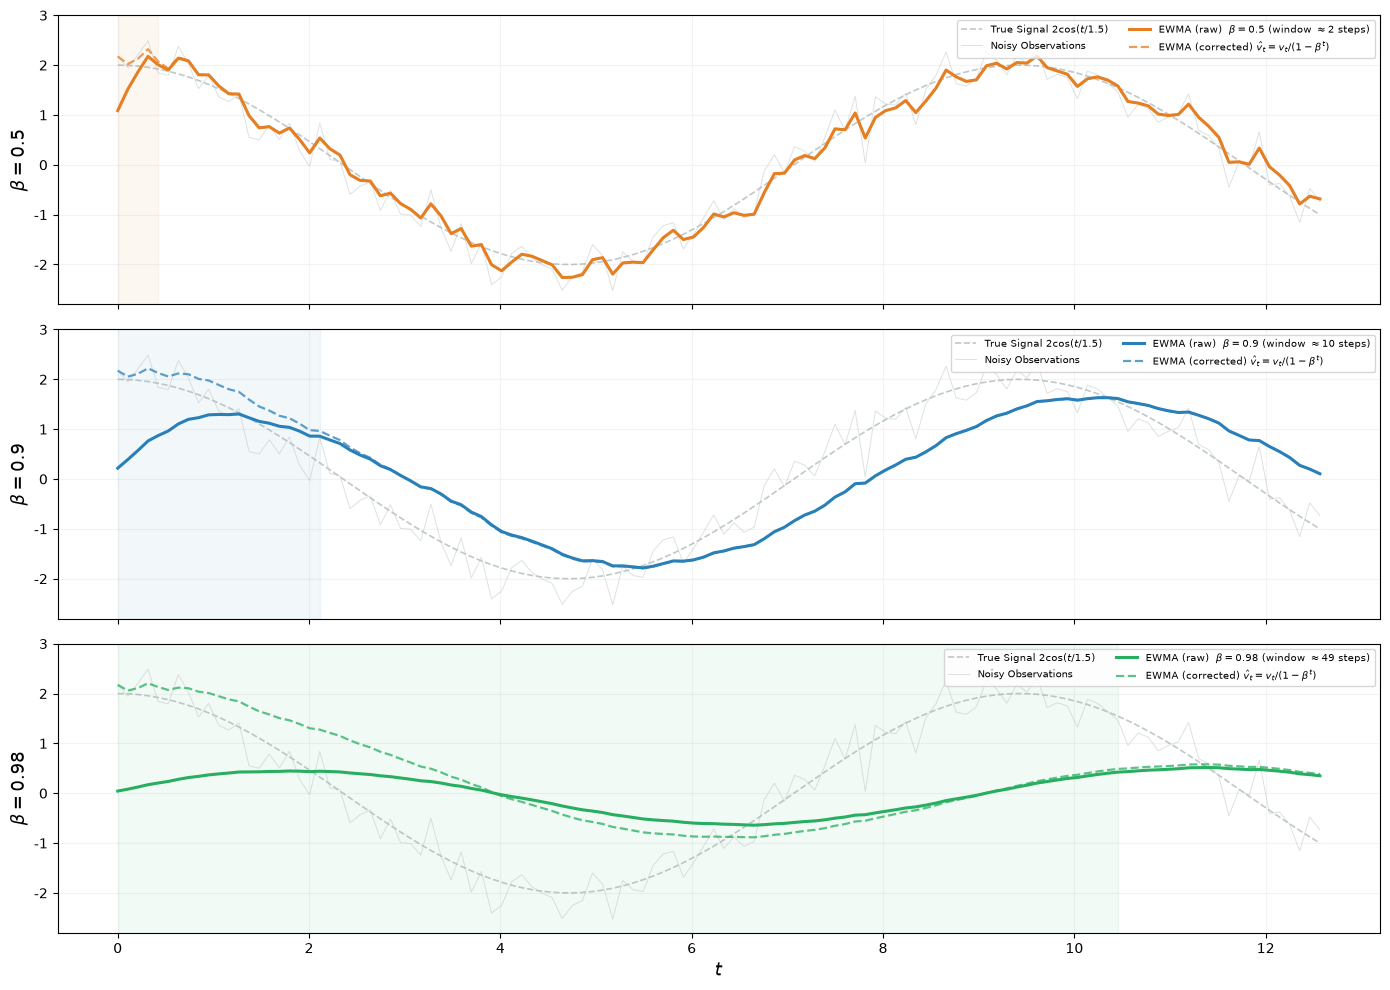

EWMA static comparison saved to: ../attachment/EWMA_comparison.png
EWMA animation GIF saved to: ../attachment/EWMA_animation.gif
Done!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# --- Generate noisy data (shifted cosine + Gaussian noise) ---
# Using 2·cos(t/1.5) instead of sin(t): starts at 2.0 ≠ 0, so the cold-start
# underestimation from v_0 = 0 is immediately visible
np.random.seed(42)
n_points = 120
t = np.linspace(0, 4 * np.pi, n_points)
clean = 2.0 * np.cos(t / 1.5)                # clean signal — starts at 2.0, non-linear
noise = np.random.randn(n_points) * 0.35      # Gaussian noise
noisy = clean + noise                         # observed sequence

# --- EWMA computation functions ---
def ewma_raw(sequence, beta):
    """Standard EWMA (v_0 = 0, no bias correction). Early values are systematically biased toward zero."""
    v = np.zeros_like(sequence)
    # v_0 = 0, so v_1 = (1-beta)*x_1
    for i in range(len(sequence)):
        if i == 0:
            v[i] = (1 - beta) * sequence[i]
        else:
            v[i] = beta * v[i-1] + (1 - beta) * sequence[i]
    return v

def ewma_corrected(sequence, beta):
    """Bias-corrected EWMA: \hat{v}_t = v_t / (1 - beta^t)"""
    v_raw = ewma_raw(sequence, beta)
    t_indices = np.arange(1, len(sequence) + 1)
    correction = 1 - beta ** t_indices
    return v_raw / correction

# --- EWMA with different beta values (both raw and corrected) ---
betas = [0.5, 0.9, 0.98]
ewma_raw_curves = {b: ewma_raw(noisy, b) for b in betas}
ewma_corrected_curves = {b: ewma_corrected(noisy, b) for b in betas}

# ============================================================
# Part 1: Static comparison
# Each subplot shows: raw EWMA (solid) + bias-corrected EWMA (dashed)
# Note: the early-stage gap grows more pronounced as beta increases
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors = {0.5: '#E67E22', 0.9: '#2980B9', 0.98: '#27AE60'}
for idx, beta in enumerate(betas):
    ax = axes[idx]
    # True signal & noisy observations
    ax.plot(t, clean, '--', color='#95A5A6', linewidth=1.2, alpha=0.6,
            label=r'True Signal $2\cos(t/1.5)$')
    ax.plot(t, noisy, '-', color='#BDC3C7', linewidth=0.7, alpha=0.5,
            label='Noisy Observations')
    # Raw EWMA (solid, biased — pulled toward zero early on)
    ax.plot(t, ewma_raw_curves[beta], '-', color=colors[beta], linewidth=2.2,
            label=f'EWMA (raw)  $\\beta={beta}$ (window $\\approx {int(1/(1-beta))}$ steps)')
    # Bias-corrected EWMA (dashed, cold-start corrected)
    ax.plot(t, ewma_corrected_curves[beta], '--', color=colors[beta], linewidth=1.6,
            alpha=0.75,
            label=f'EWMA (corrected) $\\hat{{v}}_t = v_t/(1-\\beta^t)$')

    # Highlight warmup region (first 2/(1-beta) steps)
    warmup = int(2 / (1 - beta))
    ax.axvspan(0, t[min(warmup, n_points-1)], alpha=0.06, color=colors[beta])

    ax.set_ylabel(f'$\\beta = {beta}$', fontsize=13, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.15)
    ax.set_ylim(-2.8, 3.0)

axes[-1].set_xlabel('$t$', fontsize=13)
plt.tight_layout()
plt.savefig('../attachment/EWMA_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('EWMA static comparison saved to: ../attachment/EWMA_comparison.png')

# ============================================================
# Part 2: Animated GIF — EWMA step-by-step accumulation + bias correction
# Left: Data stream + EWMA dynamic update (raw vs corrected)
# Right: Exponential weight distribution at current step
# ============================================================
beta_demo = 0.9
v_raw = ewma_raw(noisy, beta_demo)
v_corrected = ewma_corrected(noisy, beta_demo)

fig2, (ax_main, ax_weight) = plt.subplots(1, 2, figsize=(17, 6.5))

def animate_ewma(frame):
    ax_main.clear(); ax_weight.clear()

    # --- Left: Signal & EWMA estimates ---
    # Observed data points (small gray dots)
    ax_main.plot(t[:frame+1], noisy[:frame+1], 'o', color='#BDC3C7',
                 markersize=2.5, alpha=0.4, label=r'Observed Data $x_t$')
    # True signal (semi-transparent dashed)
    ax_main.plot(t, clean, '--', color='#95A5A6', linewidth=1.5, alpha=0.5,
                 label=r'True Signal $2\cos(t/1.5)$')
    # Raw EWMA estimate (red line — dragged toward zero in early steps)
    ax_main.plot(t[:frame+1], v_raw[:frame+1], '-', color='#E74C3C', linewidth=2.2,
                 alpha=0.7,
                 label=f'EWMA (raw) $v_t$, $\\beta={beta_demo}$')
    # Bias-corrected EWMA estimate (blue dashed — cold-start corrected)
    ax_main.plot(t[:frame+1], v_corrected[:frame+1], '--', color='#2980B9', linewidth=2.2,
                 alpha=0.85,
                 label=f'EWMA (corrected) $\\hat{{v}}_t = v_t/(1-\\beta^t)$')

    # Highlight current observation
    if frame < n_points:
        ax_main.scatter([t[frame]], [noisy[frame]], color='#2C3E50', s=80,
                        zorder=10, edgecolors='white', linewidth=1.5)
        ax_main.annotate(f'$x_{{{frame}}}$', xy=(t[frame], noisy[frame]),
                         xytext=(t[frame]+0.15, noisy[frame]+0.3),
                         fontsize=11, fontweight='bold', color='#2C3E50',
                         arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.2))

    # Display bias correction factor
    if frame > 0:
        correction_factor = 1 - beta_demo ** (frame + 1)
        if correction_factor < 0.95:
            ax_main.text(0.02, 0.12,
                         f'Bias Correction: $1-\\beta^t = {correction_factor:.3f}$\n'
                         f'Amplification: $1/(1-\\beta^t) = {1/correction_factor:.2f}$',
                         transform=ax_main.transAxes, fontsize=10,
                         verticalalignment='bottom',
                         bbox=dict(boxstyle='round', facecolor='#2980B9',
                                   alpha=0.12, edgecolor='#2980B9', linewidth=0.8))

    ax_main.set_xlabel('$t$', fontsize=13)
    ax_main.set_ylabel('Value', fontsize=13)
    ax_main.set_title(f'EWMA Dynamic Update Process ($\\beta={beta_demo}$)\n'
                      f'Step $t={{{frame}}}$, '
                      f'$v_{{{frame}}}={{{v_raw[frame]:.3f}}}$, '
                      f'$\\hat{{v}}_{{{frame}}}={{{v_corrected[frame]:.3f}}}$',
                      fontsize=12, fontweight='bold')
    ax_main.legend(fontsize=7.5, loc='upper right')
    ax_main.set_xlim(t[0], t[-1])
    ax_main.set_ylim(-2.8, 3.2)
    ax_main.grid(True, alpha=0.15)

    # --- Right: Exponential weight distribution ---
    if frame > 0:
        # Compute weights for each historical value: w_i = (1-beta) * beta^i (from oldest to newest)
        weights = [(1 - beta_demo) * beta_demo ** i for i in range(frame)]
        weights = weights[::-1]  # reverse: left=old, right=recent

        bars = ax_weight.bar(range(len(weights)), weights, color='#E74C3C',
                             alpha=0.7, width=0.8)
        ax_weight.axhline(y=0, color='black', linewidth=0.3)

        # Annotate weights of the last two steps
        ax_weight.annotate(f'$x_{{{frame}}}$: {weights[-1]:.3f}',
                           xy=(len(weights)-1, weights[-1]),
                           fontsize=9, fontweight='bold', color='#E74C3C',
                           ha='center', va='bottom')
        if len(weights) > 1:
            ax_weight.annotate(f'$x_{{{frame-1}}}$: {weights[-2]:.3f}',
                               xy=(len(weights)-2, weights[-2]),
                               fontsize=8, color='#E74C3C', ha='center', va='bottom')

    # Weight sum (should approach 1-beta^t, eventually converging to 1)
    if frame > 0:
        weight_sum = (1 - beta_demo) * (1 - beta_demo ** frame) / (1 - beta_demo)
        ax_weight.text(0.98, 0.95,
                       f'Weight Sum = {weight_sum:.4f}\n'
                       f'($= 1 - \\beta^{{{frame}}} = 1 - {beta_demo}^{{{frame}}}$)',
                       transform=ax_weight.transAxes, fontsize=9,
                       verticalalignment='top', horizontalalignment='right',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax_weight.set_xlabel('Historical Steps (Left = Old, Right = Recent)', fontsize=12)
    ax_weight.set_ylabel('Weight', fontsize=12)
    ax_weight.set_title(f'Weight Distribution of Historical Values in Current EWMA\n'
                        f'$v_{{{frame}}} = (1-\\beta)\\sum_{{i=0}}^{{{frame-1}}}\\beta^{{i}} x_{{{frame}-i}}$',
                        fontsize=12, fontweight='bold')
    ax_weight.set_ylim(0, 0.15)
    ax_weight.grid(True, alpha=0.15, axis='y')

    fig2.suptitle(f'Exponentially Weighted Moving Average (EWMA) · Step-by-Step Accumulation + Bias Correction · $\\beta = {beta_demo}$',
                  fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    return []

ani_ewma = animation.FuncAnimation(fig2, animate_ewma,
                                    frames=range(0, n_points, 2),
                                    interval=120, blit=False, repeat=True)

gif_path_ewma = '../attachment/EWMA_animation.gif'
ani_ewma.save(gif_path_ewma, writer=PillowWriter(fps=8), dpi=100)
print(f'EWMA animation GIF saved to: {gif_path_ewma}')
plt.close()
print('Done!')

### 6.1.3 动量法的数学推导

理解了 EWMA 之后，动量法的数学形式就很容易理解了。

#### 核心思想

标准 SGD 的参数更新完全依赖当前梯度：

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \cdot \mathbf{g}_t, \quad \mathbf{g}_t = \nabla_{\boldsymbol{\theta}}\mathcal{L}(\boldsymbol{\theta}_t)$$

如果 $\mathbf{g}_t$ 噪声很大（SGD 使用单样本或小批量时的固有问题），参数更新方向也会剧烈波动。

动量法的解决思路很自然：**不要直接用原始梯度，而是用梯度的指数加权移动平均来更新参数。** 这样，那些来回震荡的梯度分量会在加权平均中相互抵消，而那些持续指向同一方向的梯度分量则会不断累积增强。

#### 数学形式

引入**速度** $\mathbf{v}_t$ 作为历史梯度的指数加权移动平均：

$$\boxed{\mathbf{v}_0 = \mathbf{0}}$$

$$\boxed{\mathbf{v}_t = \beta \cdot \mathbf{v}_{t-1} + \eta \cdot \nabla_{\boldsymbol{\theta}}\mathcal{L}(\boldsymbol{\theta}_t)}$$

其中：
- $\beta \in [0, 1)$ 是**动量参数**（通常取 0.9），控制历史梯度的影响程度
- $\eta$ 是学习率
- $\mathbf{v}_t$ 称为**速度（velocity）**——它累积了梯度历史的方向和大小

参数更新不再使用原始梯度，而是使用累积的速度：

$$\boxed{\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \mathbf{v}_t}$$

#### 展开形式：动量法是对历史梯度的指数加权

将速度的递推式层层展开，可以清晰地看到 EWMA 的结构：

$$\begin{aligned}
\mathbf{v}_t &= \eta \cdot \mathbf{g}_t + \beta \cdot \mathbf{v}_{t-1} \\
             &= \eta \cdot \mathbf{g}_t + \beta\big(\eta \cdot \mathbf{g}_{t-1} + \beta \cdot \mathbf{v}_{t-2}\big) \\
             &= \eta \cdot \mathbf{g}_t + \eta\beta \cdot \mathbf{g}_{t-1} + \eta\beta^2 \cdot \mathbf{g}_{t-2} + \cdots
\end{aligned}$$

$$\boxed{\mathbf{v}_t = \eta \sum_{i=0}^{t-1} \beta^{i} \cdot \mathbf{g}_{t-i}}$$

$$\boxed{\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \sum_{i=0}^{t-1} \beta^{i} \cdot \mathbf{g}_{t-i}}$$

这正是对历史梯度序列的**指数加权移动平均**！最近一步的梯度 $\mathbf{g}_t$ 权重为 $\eta$，前一步 $\mathbf{g}_{t-1}$ 权重为 $\eta\beta$，再往前权重为 $\eta\beta^2$……以 $\beta$ 为底指数衰减。

#### 另一种等价形式

有时你也会看到动量法被写为与 EWMA 定义在形式上完全对齐的版本：

$$\boxed{\mathbf{m}_t = \beta \cdot \mathbf{m}_{t-1} + (1-\beta) \cdot \mathbf{g}_t}$$

$$\boxed{\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \tilde{\eta} \cdot \mathbf{m}_t}$$

两种写法本质等价（只需令 $\tilde{\eta} = \eta/(1-\beta)$ 即可相互转换）。实际工程中，前一种形式（$\mathbf{v}_t = \beta\mathbf{v}_{t-1} + \eta\mathbf{g}_t$）更为常见，因为它把学习率 $\eta$ 直接放在梯度项前面，含义更直观。

Momentum comparison GIF saved to: ../attachment/Momentum_vs_SGD_animation.gif


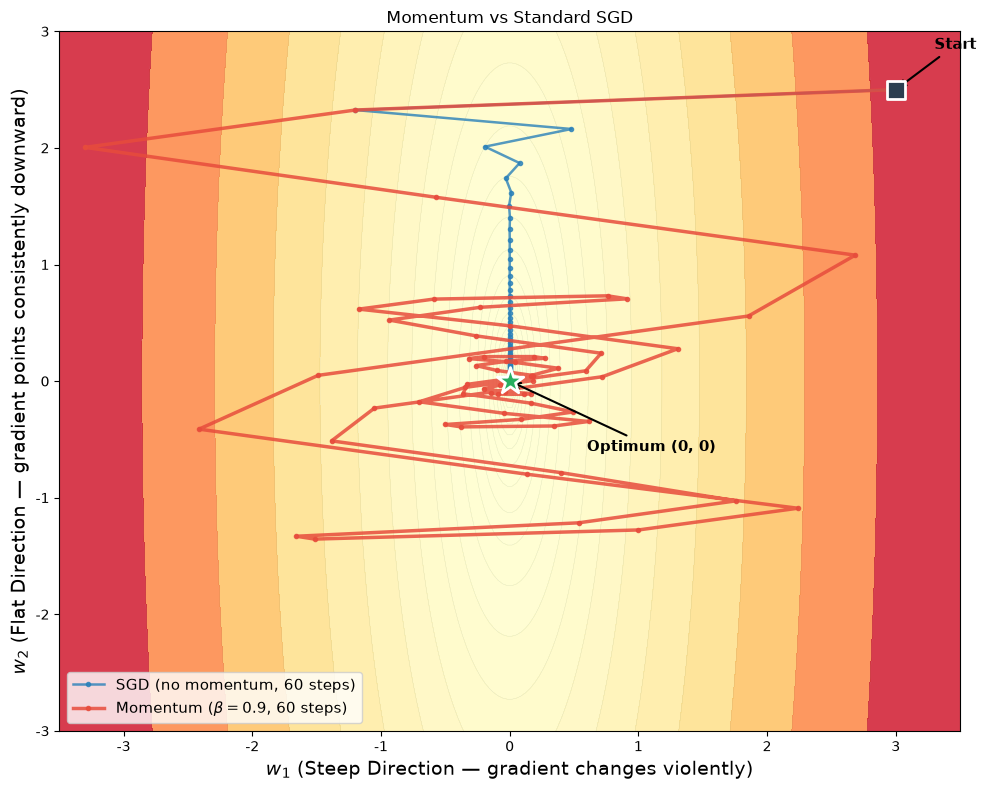

Final trajectory static plot saved


In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

a = 20  # condition number = 20, w1 direction is 20x steeper

def loss_fn(w1, w2):
    return 0.5 * (a * w1**2 + w2**2)

def gradient(w1, w2):
    return np.array([a * w1, w2])

# ============================================================
# Parameter settings
# ============================================================
w_init = np.array([3.0, 2.5])  # initial point (far from optimum)
lr = 0.07                       # learning rate
beta = 0.9                      # momentum parameter
n_steps = 60                    # number of iterations

# --- SGD trajectory ---
w_sgd = np.zeros((n_steps + 1, 2))
w_sgd[0] = w_init
loss_sgd = np.zeros(n_steps + 1)
loss_sgd[0] = loss_fn(*w_init)

for t in range(n_steps):
    g = gradient(*w_sgd[t])
    w_sgd[t+1] = w_sgd[t] - lr * g
    loss_sgd[t+1] = loss_fn(*w_sgd[t+1])

# --- Momentum trajectory ---
w_mom = np.zeros((n_steps + 1, 2))
w_mom[0] = w_init
v = np.zeros(2)         # velocity initialized to zero
loss_mom = np.zeros(n_steps + 1)
loss_mom[0] = loss_fn(*w_init)

for t in range(n_steps):
    g = gradient(*w_mom[t])
    v = beta * v + lr * g         # velocity = momentum * old velocity + learning_rate * current gradient
    w_mom[t+1] = w_mom[t] - v     # update parameters using velocity (not raw gradient)
    loss_mom[t+1] = loss_fn(*w_mom[t+1])

# ============================================================
# Build contour grid (vectorized computation via numpy broadcasting)
# ============================================================
grid_size = 200
w1_range = np.linspace(-3.5, 3.5, grid_size)
w2_range = np.linspace(-3, 3, grid_size)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = loss_fn(W1, W2)  # vectorized: compute entire grid at once

levels = np.logspace(np.log10(max(Z.min(), 1e-4)), np.log10(Z.max()), 25)

# ============================================================
# GIF Animation: Dual panel — parameter trajectory + loss curve
# ============================================================
fig, (ax_contour, ax_loss_curve) = plt.subplots(1, 2, figsize=(17, 7))

def animate_momentum(frame):
    ax_contour.clear(); ax_loss_curve.clear()

    # --- Panel A: Parameter space contour + trajectory ---
    ax_contour.contourf(W1, W2, Z, levels=levels, cmap='YlOrRd', alpha=0.8)
    ax_contour.contour(W1, W2, Z, levels=levels, colors='#B0BEC5',
                        linewidths=0.3, alpha=0.4)

    # SGD trajectory (blue)
    ax_contour.plot(w_sgd[:frame+1, 0], w_sgd[:frame+1, 1], '-',
                    color='#2980B9', linewidth=2.2, alpha=0.85,
                    label='SGD (no momentum)')
    ax_contour.scatter(*w_sgd[frame], color='#2980B9', s=80, zorder=10,
                       edgecolors='white', linewidth=2)

    # Momentum trajectory (red)
    ax_contour.plot(w_mom[:frame+1, 0], w_mom[:frame+1, 1], '-',
                    color='#E74C3C', linewidth=2.8, alpha=0.9,
                    label=f'Momentum ($\\beta={beta}$)')
    ax_contour.scatter(*w_mom[frame], color='#E74C3C', s=80, zorder=10,
                       edgecolors='white', linewidth=2)

    # Start marker & optimum marker
    ax_contour.scatter([w_init[0]], [w_init[1]], marker='s', color='#2C3E50',
                       s=120, zorder=12, edgecolors='white', linewidth=1.5)
    ax_contour.annotate('Start', xy=(w_init[0], w_init[1]), fontsize=10,
                        fontweight='bold', color='#2C3E50',
                        xytext=(w_init[0]+0.3, w_init[1]+0.3),
                        arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.2))

    ax_contour.scatter([0], [0], marker='*', color='#27AE60', s=350, zorder=12,
                       edgecolors='white', linewidth=1.5)
    ax_contour.annotate('Optimum', xy=(0, 0), fontsize=10, fontweight='bold',
                        color='#27AE60', xytext=(0.5, -0.5),
                        arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.2))

    # Step counter
    ax_contour.text(0.02, 0.98, f'Iteration: {frame}/{n_steps}',
                    transform=ax_contour.transAxes, fontsize=12, fontweight='bold',
                    verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax_contour.set_xlabel(r'$w_1$ (Steep Direction — large gradient, sign alternates)', fontsize=13)
    ax_contour.set_ylabel(r'$w_2$ (Flat Direction — small gradient, consistent sign)', fontsize=13)
    ax_contour.set_title(f'Parameter Space · Loss Contours\n'
                         f'$f(w_1, w_2) = \\frac{{1}}{{2}}({a}w_1^2 + w_2^2)$, '
                         f'Condition Number = {a}',
                         fontsize=13, fontweight='bold')
    ax_contour.legend(fontsize=10, loc='lower left')
    ax_contour.set_xlim(-3.5, 3.5); ax_contour.set_ylim(-3, 3)

    # --- Panel B: Loss curve ---
    ax_loss_curve.plot(loss_sgd[:frame+1], '-', color='#2980B9', linewidth=2.0,
                       alpha=0.85, label='SGD (no momentum)')
    ax_loss_curve.plot(loss_mom[:frame+1], '-', color='#E74C3C', linewidth=2.5,
                       alpha=0.9, label=f'Momentum ($\\beta={beta}$)')

    ax_loss_curve.set_xlabel('Iteration', fontsize=13)
    ax_loss_curve.set_ylabel('Loss', fontsize=13)
    ax_loss_curve.set_title(f'Loss Curve\n'
                            f'SGD Loss = {loss_sgd[frame]:.4f}  |  '
                            f'Momentum Loss = {loss_mom[frame]:.4f}',
                            fontsize=13, fontweight='bold')
    ax_loss_curve.legend(fontsize=10, loc='upper right')
    ax_loss_curve.set_xlim(0, n_steps)
    ax_loss_curve.set_ylim(-0.5, max(loss_sgd[0], loss_mom[0]) * 1.05)
    ax_loss_curve.grid(True, alpha=0.2)

    fig.suptitle('Momentum vs Standard SGD · Comparison in a Narrow Valley',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return []

ani_momentum = animation.FuncAnimation(fig, animate_momentum,
                                        frames=range(0, n_steps + 1, 1),
                                        interval=180, blit=False, repeat=True)

gif_path_mom = '../attachment/Momentum_vs_SGD_animation.gif'
ani_momentum.save(gif_path_mom, writer=PillowWriter(fps=8), dpi=100)
print(f'Momentum comparison GIF saved to: {gif_path_mom}')
plt.close()

# ============================================================
# Static summary plot: Full trajectory overview
# ============================================================
fig2, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.contourf(W1, W2, Z, levels=levels, cmap='YlOrRd', alpha=0.8)
ax.contour(W1, W2, Z, levels=levels, colors='#B0BEC5', linewidths=0.3, alpha=0.4)

# Two complete trajectories
ax.plot(w_sgd[:, 0], w_sgd[:, 1], '-o', color='#2980B9', linewidth=1.8,
        markersize=3, alpha=0.8, label=f'SGD (no momentum, {n_steps} steps)')
ax.plot(w_mom[:, 0], w_mom[:, 1], '-o', color='#E74C3C', linewidth=2.5,
        markersize=3, alpha=0.85, label=f'Momentum ($\\beta={beta}$, {n_steps} steps)')

# Key annotations
ax.scatter([w_init[0]], [w_init[1]], marker='s', color='#2C3E50', s=150,
           zorder=12, edgecolors='white', linewidth=2)
ax.annotate('Start', xy=(w_init[0], w_init[1]), fontsize=11, fontweight='bold',
            xytext=(w_init[0]+0.3, w_init[1]+0.35),
            arrowprops=dict(arrowstyle='->', lw=1.5))

ax.scatter([0], [0], marker='*', color='#27AE60', s=400, zorder=12,
           edgecolors='white', linewidth=2)
ax.annotate('Optimum (0, 0)', xy=(0, 0), fontsize=11, fontweight='bold',
            xytext=(0.6, -0.6),
            arrowprops=dict(arrowstyle='->', lw=1.5))

ax.set_xlabel(r'$w_1$ (Steep Direction — gradient changes violently)', fontsize=14)
ax.set_ylabel(r'$w_2$ (Flat Direction — gradient points consistently downward)', fontsize=14)
ax.set_title('Momentum vs Standard SGD')
ax.legend(fontsize=11, loc='lower left')
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3, 3)

plt.tight_layout()
plt.savefig('../attachment/Momentum_vs_SGD_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final trajectory static plot saved')

## 6.2 Nestrov 加速动量法



## 6.3 Adam